# 41 — Input-only turnover and persistence audit

**Question.** Can the continuous adaptive-dispersion strategy inherited from
LSEG/Gemma be made materially cheaper through one simple persistence rule,
without selecting anything on realised returns?

**Inputs and boundary.** This notebook uses Notebook 39's complete
888,155-headline Gemma 26B input-only schedule and FNSPID's FinBERT
`mean_continuous` signal panel plus Notebook 40's signal-only schedule. It
never loads a price or return column. LSEG and FNSPID remain separate regimes.

**Single candidate fixed before diagnostics.** On the first active session of
a consecutive active episode, form the usual long/short rank book. On later
consecutive active sessions, keep the episode-opening names and weights. Exit
to cash on the first inactive session. This changes only active-to-active
reconstitution; the dispersion trigger, breadth, cap, neutrality, and cash
rule are unchanged.

**Input-only gate.** The episode-hold candidate is eligible for a future
new-date return test only if, in LSEG/Gemma, FNSPID development, and FNSPID
evaluation separately: (i) at least ten active episodes exist; (ii) target-L1
turnover falls by at least 15%; and (iii) mean continuation-session Jaccard is
at least 0.50 in both long and short legs. Failure stops the rule before any
return test. Passing would establish feasibility only, not alpha.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from collections.abc import Mapping, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402

SEED = 20260815
COST_BPS_PER_SIDE = 10.0
RELATIVE_BREADTH = 2.0 / 33.0
MINIMUM_NAMES_PER_LEG = 2
MINIMUM_EPISODES = 10
MINIMUM_TURNOVER_REDUCTION = 0.15
MINIMUM_CONTINUATION_JACCARD = 0.50

FNSPID_SIGNAL_PATH = (
    REPO_ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"
)
FNSPID_SCHEDULE_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/input_schedule.csv"
)
LSEG_SCHEDULE_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/39_gemma_continuous_portability/full_26b_input_schedule.csv"
)
NOTEBOOK39_MANIFEST_PATH = (
    REPO_ROOT / "final_experiments/outputs/39_gemma_continuous_portability/manifest.json"
)
OUTPUT_DIR = (
    REPO_ROOT / "final_experiments/outputs/41_input_only_turnover_persistence"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Validate the return-free contract

The selected Notebook 39 reducer and adaptive schedule are rebound here. The
FNSPID parquet read explicitly requests four signal/calendar fields; a schema
audit rejects accidental outcome columns.

In [2]:
notebook39_manifest = json.loads(NOTEBOOK39_MANIFEST_PATH.read_text())
selected_spec = notebook39_manifest["selected_future_specification"]
expected_spec = {
    "firm_open_reducer": "mean_continuous",
    "long_names": 2,
    "short_names": 2,
    "single_name_cap": 0.25,
    "gross_exposure": 1.0,
    "holding_intervals": 1,
    "cost_bps_per_side_for_future_test": 10.0,
    "current_return_window_evaluated": False,
}
for key, expected in expected_spec.items():
    if selected_spec.get(key) != expected:
        raise ValueError(f"Notebook 39 specification mismatch for {key}")
if notebook39_manifest["adaptive_schedule"] != {
    "top_bottom_names": 2,
    "trailing_sessions": 60,
    "minimum_trailing_sessions": 40,
    "event_intensity_quantile": 0.75,
}:
    raise ValueError("Notebook 39 adaptive schedule changed")

signal_columns = ["symbol", "session_date", "split", "mean_continuous"]
forbidden_tokens = ("return", "ret_", "price", "open", "close", "adj_")
if any(
    token in column.lower()
    for column in signal_columns
    for token in forbidden_tokens
):
    raise RuntimeError("return-free signal schema includes a forbidden outcome token")

fnspid_signal = pd.read_parquet(FNSPID_SIGNAL_PATH, columns=signal_columns)
fnspid_signal["session_date"] = pd.to_datetime(
    fnspid_signal["session_date"]
).dt.normalize()
fnspid_signal = fnspid_signal.sort_values(
    ["session_date", "symbol"], kind="mergesort"
).reset_index(drop=True)
if fnspid_signal.duplicated(["session_date", "symbol"]).any():
    raise ValueError("FNSPID signal is not unique by firm-session")
if fnspid_signal["mean_continuous"].isna().any():
    raise ValueError("FNSPID mean-continuous signal contains missing values")

fnspid_schedule = pd.read_csv(FNSPID_SCHEDULE_PATH, parse_dates=["session_date"])
lseg_schedule = pd.read_csv(LSEG_SCHEDULE_PATH, parse_dates=["session_date"])
required_fnspid = {
    "session_date",
    "split",
    "available_names",
    "active",
    "names_per_leg",
}
required_lseg = {
    "session_date",
    "spread",
    "trailing_threshold",
    "active",
    "long_symbols",
    "short_symbols",
}
if not required_fnspid.issubset(fnspid_schedule.columns):
    raise ValueError("Notebook 40 input schedule schema changed")
if not required_lseg.issubset(lseg_schedule.columns):
    raise ValueError("Notebook 39 full schedule schema changed")
if len(fnspid_schedule) != fnspid_signal["session_date"].nunique():
    raise ValueError("FNSPID signal and schedule session counts differ")

input_audit = pd.DataFrame(
    [
        {
            "regime": "LSEG/Gemma 26B",
            "sessions": len(lseg_schedule),
            "active_sessions": int(lseg_schedule["active"].sum()),
            "sentiment_scorer": "Gemma 4 26B DeepInfra FP8",
            "return_columns_loaded": False,
        },
        {
            "regime": "FNSPID/FinBERT",
            "sessions": len(fnspid_schedule),
            "active_sessions": int(fnspid_schedule["active"].sum()),
            "sentiment_scorer": "ProsusAI/FinBERT",
            "return_columns_loaded": False,
        },
    ]
)
display(input_audit)

,regime,sessions,active_sessions,sentiment_scorer,return_columns_loaded
0,LSEG/Gemma 26B,167,40,Gemma 4 26B DeepInfra FP8,False
1,FNSPID/FinBERT,3262,831,ProsusAI/FinBERT,False


## Reconstruct the frozen fresh targets

Each active target has gross exposure one and zero net exposure. LSEG uses the
exact Gemma-selected two-name symbol lists saved by Notebook 39. FNSPID uses
Notebook 40's relative breadth and FinBERT mean-continuous ordering.

In [3]:
Target = dict[str, float]


def split_symbols(value: object) -> list[str]:
    if pd.isna(value):
        return []
    return [part for part in str(value).split("|") if part]


def equal_leg_target(long_symbols: Sequence[str], short_symbols: Sequence[str]) -> Target:
    if not long_symbols and not short_symbols:
        return {}
    if not long_symbols or not short_symbols:
        raise ValueError("one-sided target is not allowed")
    if set(long_symbols) & set(short_symbols):
        raise ValueError("long and short targets overlap")
    target = {symbol: 0.5 / len(long_symbols) for symbol in long_symbols}
    target.update({symbol: -0.5 / len(short_symbols) for symbol in short_symbols})
    if not np.isclose(sum(abs(weight) for weight in target.values()), 1.0):
        raise ValueError("target gross exposure is not one")
    if not np.isclose(sum(target.values()), 0.0):
        raise ValueError("target is not dollar neutral")
    return target


def build_lseg_targets(schedule: pd.DataFrame) -> list[Target]:
    targets: list[Target] = []
    for row in schedule.itertuples(index=False):
        if not bool(row.active):
            targets.append({})
            continue
        targets.append(
            equal_leg_target(
                split_symbols(row.long_symbols), split_symbols(row.short_symbols)
            )
        )
    return targets


def build_fnspid_targets(
    signal: pd.DataFrame, schedule: pd.DataFrame
) -> list[Target]:
    schedule_lookup = schedule.set_index("session_date")
    targets: list[Target] = []
    seen_dates: list[pd.Timestamp] = []
    for session, day in signal.groupby("session_date", sort=True):
        session = pd.Timestamp(session)
        seen_dates.append(session)
        row = schedule_lookup.loc[session]
        if not bool(row["active"]):
            targets.append({})
            continue
        ordered = day.sort_values(
            ["mean_continuous", "symbol"],
            ascending=[True, True],
            kind="mergesort",
        )
        names_per_leg = int(row["names_per_leg"])
        expected_names = max(
            MINIMUM_NAMES_PER_LEG,
            int(np.ceil(int(row["available_names"]) * RELATIVE_BREADTH)),
        )
        if names_per_leg != expected_names:
            raise ValueError("FNSPID relative breadth changed")
        targets.append(
            equal_leg_target(
                ordered["symbol"].iloc[-names_per_leg:].tolist(),
                ordered["symbol"].iloc[:names_per_leg].tolist(),
            )
        )
    if seen_dates != schedule["session_date"].tolist():
        raise ValueError("FNSPID target dates do not match the saved input schedule")
    return targets


lseg_targets = build_lseg_targets(lseg_schedule)
fnspid_targets = build_fnspid_targets(fnspid_signal, fnspid_schedule)

## Persistence rule and target-only accounting

Turnover is the L1 change in intended weights from the prior target, including
final liquidation. It deliberately excludes return-induced drift because no
return is loaded. Transition categories show whether costs come from entering
and leaving cash or from changing names while the trigger remains active.

In [4]:
def target_l1(left: Mapping[str, float], right: Mapping[str, float]) -> float:
    symbols = set(left) | set(right)
    return float(sum(abs(right.get(symbol, 0.0) - left.get(symbol, 0.0)) for symbol in symbols))


def selected_leg(target: Mapping[str, float], positive: bool) -> set[str]:
    if positive:
        return {symbol for symbol, weight in target.items() if weight > 0}
    return {symbol for symbol, weight in target.items() if weight < 0}


def jaccard(left: set[str], right: set[str]) -> float:
    if not left and not right:
        return 1.0
    return len(left & right) / len(left | right)


def episode_hold_targets(fresh_targets: Sequence[Target]) -> list[Target]:
    held: Target = {}
    output: list[Target] = []
    prior_active = False
    for fresh in fresh_targets:
        active = bool(fresh)
        if not active:
            held = {}
        elif not prior_active:
            held = dict(fresh)
        output.append(dict(held))
        prior_active = active
    return output


def episode_lengths(active: np.ndarray) -> list[int]:
    lengths: list[int] = []
    current = 0
    for flag in active:
        if flag:
            current += 1
        elif current:
            lengths.append(current)
            current = 0
    if current:
        lengths.append(current)
    return lengths


def turnover_decomposition(targets: Sequence[Target]) -> dict[str, float]:
    totals = {
        "cash_to_cash": 0.0,
        "cash_to_active": 0.0,
        "active_to_cash": 0.0,
        "active_to_active": 0.0,
        "terminal_liquidation": 0.0,
    }
    prior: Target = {}
    for target in targets:
        if prior and target:
            category = "active_to_active"
        elif prior:
            category = "active_to_cash"
        elif target:
            category = "cash_to_active"
        else:
            category = "cash_to_cash"
        totals[category] += target_l1(prior, target)
        prior = dict(target)
    totals["terminal_liquidation"] = target_l1(prior, {})
    return totals


def audit_regime(
    regime: str,
    dates: pd.Series,
    fresh_targets: Sequence[Target],
) -> tuple[dict[str, object], pd.DataFrame, pd.DataFrame]:
    if len(dates) != len(fresh_targets):
        raise ValueError("dates and targets have different lengths")
    active = np.array([bool(target) for target in fresh_targets], dtype=bool)
    held_targets = episode_hold_targets(fresh_targets)
    runs = episode_lengths(active)
    fresh_decomposition = turnover_decomposition(fresh_targets)
    held_decomposition = turnover_decomposition(held_targets)
    fresh_turnover = sum(fresh_decomposition.values())
    held_turnover = sum(held_decomposition.values())
    continuation = active & np.r_[False, active[:-1]]

    fidelity_rows = []
    for date, is_continuation, fresh, held in zip(
        dates, continuation, fresh_targets, held_targets, strict=True
    ):
        if not is_continuation:
            continue
        fidelity_rows.append(
            {
                "regime": regime,
                "session_date": pd.Timestamp(date),
                "long_jaccard": jaccard(
                    selected_leg(fresh, True), selected_leg(held, True)
                ),
                "short_jaccard": jaccard(
                    selected_leg(fresh, False), selected_leg(held, False)
                ),
            }
        )
    fidelity = pd.DataFrame(fidelity_rows)
    mean_long = float(fidelity["long_jaccard"].mean()) if len(fidelity) else np.nan
    mean_short = float(fidelity["short_jaccard"].mean()) if len(fidelity) else np.nan
    active_sessions = int(active.sum())
    turnover_reduction = (
        1.0 - held_turnover / fresh_turnover if fresh_turnover > 0 else np.nan
    )
    pass_gate = bool(
        len(runs) >= MINIMUM_EPISODES
        and turnover_reduction >= MINIMUM_TURNOVER_REDUCTION
        and mean_long >= MINIMUM_CONTINUATION_JACCARD
        and mean_short >= MINIMUM_CONTINUATION_JACCARD
    )
    summary = {
        "regime": regime,
        "sessions": len(fresh_targets),
        "active_sessions": active_sessions,
        "active_share": active_sessions / len(fresh_targets),
        "active_episodes": len(runs),
        "continuation_sessions": int(continuation.sum()),
        "mean_episode_length": float(np.mean(runs)) if runs else np.nan,
        "median_episode_length": float(np.median(runs)) if runs else np.nan,
        "maximum_episode_length": int(max(runs)) if runs else 0,
        "multi_day_active_share": (
            sum(length for length in runs if length >= 2) / active_sessions
            if active_sessions
            else np.nan
        ),
        "fresh_target_l1_turnover": fresh_turnover,
        "episode_hold_target_l1_turnover": held_turnover,
        "turnover_reduction": turnover_reduction,
        "fresh_cost_load_bps_per_active_session": (
            fresh_turnover * COST_BPS_PER_SIDE / active_sessions
            if active_sessions
            else np.nan
        ),
        "episode_hold_cost_load_bps_per_active_session": (
            held_turnover * COST_BPS_PER_SIDE / active_sessions
            if active_sessions
            else np.nan
        ),
        "continuation_long_jaccard": mean_long,
        "continuation_short_jaccard": mean_short,
        "minimum_episodes_gate": len(runs) >= MINIMUM_EPISODES,
        "turnover_reduction_gate": turnover_reduction
        >= MINIMUM_TURNOVER_REDUCTION,
        "long_persistence_gate": mean_long >= MINIMUM_CONTINUATION_JACCARD,
        "short_persistence_gate": mean_short >= MINIMUM_CONTINUATION_JACCARD,
        "regime_gate": pass_gate,
    }
    decomposition_rows = []
    for policy, decomposition in (
        ("fresh_daily_rank", fresh_decomposition),
        ("episode_hold", held_decomposition),
    ):
        for transition, value in decomposition.items():
            decomposition_rows.append(
                {
                    "regime": regime,
                    "policy": policy,
                    "transition": transition,
                    "target_l1_turnover": value,
                }
            )
    return summary, pd.DataFrame(decomposition_rows), fidelity


regime_inputs: list[tuple[str, pd.Series, list[Target]]] = [
    ("LSEG/Gemma 26B", lseg_schedule["session_date"], lseg_targets),
]
for split in ("development", "evaluation"):
    mask = fnspid_schedule["split"].eq(split).to_numpy()
    regime_inputs.append(
        (
            f"FNSPID/FinBERT {split}",
            fnspid_schedule.loc[mask, "session_date"].reset_index(drop=True),
            [target for target, keep in zip(fnspid_targets, mask, strict=True) if keep],
        )
    )

summary_rows = []
decomposition_frames = []
fidelity_frames = []
for regime, dates, targets in regime_inputs:
    summary, decomposition, fidelity = audit_regime(regime, dates, targets)
    summary_rows.append(summary)
    decomposition_frames.append(decomposition)
    fidelity_frames.append(fidelity)

summary_table = pd.DataFrame(summary_rows)
turnover_decomposition_table = pd.concat(decomposition_frames, ignore_index=True)
continuation_fidelity = pd.concat(fidelity_frames, ignore_index=True)
candidate_gate = bool(summary_table["regime_gate"].all())

display(summary_table)
display(turnover_decomposition_table)

,regime,sessions,active_sessions,active_share,active_episodes,continuation_sessions,mean_episode_length,median_episode_length,maximum_episode_length,multi_day_active_share,fresh_target_l1_turnover,episode_hold_target_l1_turnover,turnover_reduction,fresh_cost_load_bps_per_active_session,episode_hold_cost_load_bps_per_active_session,continuation_long_jaccard,continuation_short_jaccard,minimum_episodes_gate,turnover_reduction_gate,long_persistence_gate,short_persistence_gate,regime_gate
0,LSEG/Gemma 26B,167,40,0.239521,23,17,1.739130,1.000000,4,0.700000,68.000000,46.000000,0.323529,17.000000,11.500000,0.274510,0.156863,True,True,False,False,False
1,FNSPID/FinBERT development,2264,570,0.251767,366,204,1.557377,1.000000,8,0.578947,"1,117.542468",732.000000,0.344991,19.606008,12.842105,0.023961,0.034632,True,True,False,False,False
2,FNSPID/FinBERT evaluation,998,261,0.261523,144,117,1.812500,1.000000,13,0.674330,507.903282,288.000000,0.432963,19.459896,11.034483,0.029242,0.028730,True,True,False,False,False


,regime,policy,transition,target_l1_turnover
0,LSEG/Gemma 26B,fresh_daily_rank,cash_to_cash,0.000000
1,LSEG/Gemma 26B,fresh_daily_rank,cash_to_active,23.000000
2,LSEG/Gemma 26B,fresh_daily_rank,active_to_cash,22.000000
3,LSEG/Gemma 26B,fresh_daily_rank,active_to_active,22.000000
4,LSEG/Gemma 26B,fresh_daily_rank,terminal_liquidation,1.000000
5,LSEG/Gemma 26B,episode_hold,cash_to_cash,0.000000
6,LSEG/Gemma 26B,episode_hold,cash_to_active,23.000000
7,LSEG/Gemma 26B,episode_hold,active_to_cash,22.000000
8,LSEG/Gemma 26B,episode_hold,active_to_active,0.000000
9,LSEG/Gemma 26B,episode_hold,terminal_liquidation,1.000000


## Visual diagnostics

The first figure separates entry/exit turnover from active-to-active name
replacement. The second shows whether the proposed hold meaningfully reduces
target changes without discarding the current extreme names.

findfont: Failed to find font weight medium, now using 400.


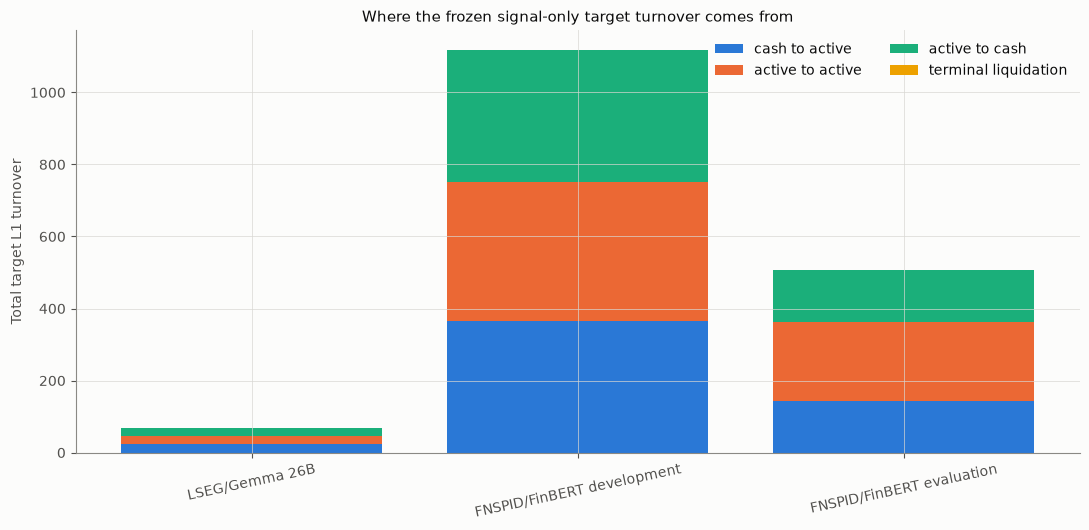

In [5]:
transition_order = [
    "cash_to_active",
    "active_to_active",
    "active_to_cash",
    "terminal_liquidation",
]
fresh_decomposition_plot = turnover_decomposition_table.loc[
    turnover_decomposition_table["policy"].eq("fresh_daily_rank")
    & turnover_decomposition_table["transition"].isin(transition_order)
].copy()
pivot = fresh_decomposition_plot.pivot(
    index="regime", columns="transition", values="target_l1_turnover"
).reindex(summary_table["regime"])

fig, ax = plt.subplots(figsize=(11.0, 5.4))
bottom = np.zeros(len(pivot))
for index, transition in enumerate(transition_order):
    values = pivot[transition].fillna(0.0).to_numpy()
    ax.bar(
        pivot.index,
        values,
        bottom=bottom,
        label=transition.replace("_", " "),
        color=CATEGORICAL[index],
    )
    bottom += values
ax.set_title("Where the frozen signal-only target turnover comes from")
ax.set_ylabel("Total target L1 turnover")
ax.tick_params(axis="x", rotation=12)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "turnover_source_decomposition.png", dpi=180)
plt.show()

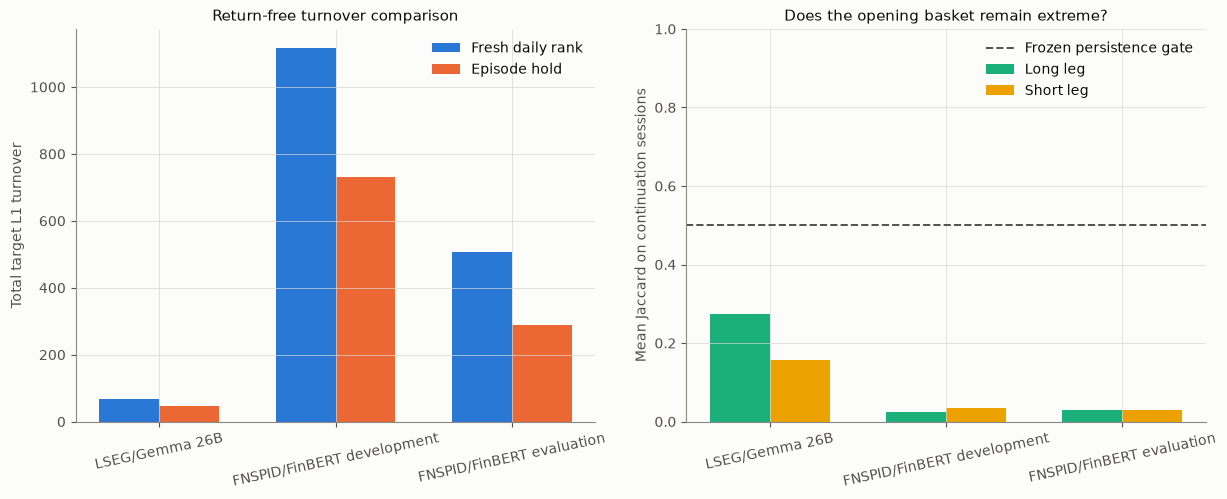

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1))
x = np.arange(len(summary_table))
width = 0.34
axes[0].bar(
    x - width / 2,
    summary_table["fresh_target_l1_turnover"],
    width,
    label="Fresh daily rank",
    color=CATEGORICAL[0],
)
axes[0].bar(
    x + width / 2,
    summary_table["episode_hold_target_l1_turnover"],
    width,
    label="Episode hold",
    color=CATEGORICAL[1],
)
axes[0].set_xticks(x, summary_table["regime"], rotation=12)
axes[0].set_ylabel("Total target L1 turnover")
axes[0].set_title("Return-free turnover comparison")
axes[0].legend(frameon=False)

axes[1].bar(
    x - width / 2,
    summary_table["continuation_long_jaccard"],
    width,
    label="Long leg",
    color=CATEGORICAL[2],
)
axes[1].bar(
    x + width / 2,
    summary_table["continuation_short_jaccard"],
    width,
    label="Short leg",
    color=CATEGORICAL[3],
)
axes[1].axhline(
    MINIMUM_CONTINUATION_JACCARD,
    color=INK["reference"],
    linestyle="--",
    linewidth=1.4,
    label="Frozen persistence gate",
)
axes[1].set_xticks(x, summary_table["regime"], rotation=12)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Mean Jaccard on continuation sessions")
axes[1].set_title("Does the opening basket remain extreme?")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "episode_hold_feasibility.png", dpi=180)
plt.show()

## Save aggregate, return-free evidence

No headline text, row-level scores, target symbol lists, prices, or returns are
written. The manifest records the exact input identities and the frozen gate.

In [7]:
summary_table.to_csv(OUTPUT_DIR / "summary.csv", index=False)
turnover_decomposition_table.to_csv(
    OUTPUT_DIR / "turnover_decomposition.csv", index=False
)
continuation_fidelity.groupby("regime", sort=False).agg(
    continuation_sessions=("session_date", "size"),
    long_jaccard_mean=("long_jaccard", "mean"),
    long_jaccard_median=("long_jaccard", "median"),
    short_jaccard_mean=("short_jaccard", "mean"),
    short_jaccard_median=("short_jaccard", "median"),
).reset_index().to_csv(OUTPUT_DIR / "continuation_fidelity.csv", index=False)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
manifest = {
    "status": "RETURN_FREE_INPUT_ONLY_TURNOVER_AUDIT",
    "notebook": "41_input_only_turnover_persistence.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "inputs": {
        "notebook39_manifest": str(NOTEBOOK39_MANIFEST_PATH.relative_to(REPO_ROOT)),
        "notebook39_manifest_sha256": sha256_file(NOTEBOOK39_MANIFEST_PATH),
        "lseg_gemma26_input_schedule": str(LSEG_SCHEDULE_PATH.relative_to(REPO_ROOT)),
        "lseg_gemma26_input_schedule_sha256": sha256_file(LSEG_SCHEDULE_PATH),
        "fnspid_signal": str(FNSPID_SIGNAL_PATH.relative_to(REPO_ROOT)),
        "fnspid_signal_sha256": sha256_file(FNSPID_SIGNAL_PATH),
        "fnspid_input_schedule": str(FNSPID_SCHEDULE_PATH.relative_to(REPO_ROOT)),
        "fnspid_input_schedule_sha256": sha256_file(FNSPID_SCHEDULE_PATH),
        "return_columns_loaded": False,
        "licensed_headline_text_loaded": False,
    },
    "candidate": {
        "name": "active_episode_opening_basket_hold",
        "rule": "refresh only on the first active session; hold names through consecutive active sessions; cash on first inactive session",
        "unchanged": [
            "mean-continuous reducer",
            "strictly-prior trailing dispersion trigger",
            "breadth",
            "single-name cap",
            "gross and net exposure",
            "cash rule",
        ],
    },
    "frozen_gate": {
        "minimum_active_episodes_each_regime": MINIMUM_EPISODES,
        "minimum_target_l1_turnover_reduction_each_regime": MINIMUM_TURNOVER_REDUCTION,
        "minimum_continuation_long_jaccard_each_regime": MINIMUM_CONTINUATION_JACCARD,
        "minimum_continuation_short_jaccard_each_regime": MINIMUM_CONTINUATION_JACCARD,
        "all_three_regimes_must_pass": True,
    },
    "regime_results": json.loads(
        summary_table.to_json(orient="records", date_format="iso")
    ),
    "candidate_gate": candidate_gate,
    "interpretation_boundary": "input-only feasibility; no performance or alpha claim",
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETURN_FREE_INPUT_ONLY_TURNOVER_AUDIT",
  "notebook": "41_input_only_turnover_persistence.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260815,
  "inputs": {
    "notebook39_manifest": "final_experiments/outputs/39_gemma_continuous_portability/manifest.json",
    "notebook39_manifest_sha256": "f24bff1a8ef71c1f7296c0bee3eba5a3ec4c2adde1bf7b8135deb05b80cd73e1",
    "lseg_gemma26_input_schedule": "final_experiments/outputs/39_gemma_continuous_portability/full_26b_input_schedule.csv",
    "lseg_gemma26_input_schedule_sha256": "f147712bbaa313a9aa16fcf984f9d474a148160336050b8aa73bc8ecc1fb5d18",
    "fnspid_signal": "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet",
    "fnspid_signal_sha256": "1ca1c38109bc06af232119adeff17de66a567174d457038bc923a930a2da61f1",
    "fnspid_input_schedule": "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/input_schedule.csv",
    "fnspid_input_schedule_sh

## Decision

**Reject the episode-hold candidate before any return test.** It reduces
signal-only target turnover by **32.35%** in LSEG/Gemma, **34.50%** in FNSPID
development, and **43.30%** in FNSPID evaluation. But the opening basket does
not remain the current extreme basket: continuation-session long/short
Jaccard is only **0.275/0.157** for LSEG/Gemma, **0.024/0.035** for FNSPID
development, and **0.029/0.029** for FNSPID evaluation. Every persistence
gate fails, so stale positions would be a different signal rather than a
cheaper implementation of the frozen one.

The accounting also identifies a structural cost floor. Removing all
active-to-active reconstitution still leaves target-only entry/exit cost loads
of **11.50**, **12.84**, and **11.03 bps per active session** in the three
regimes at the frozen 10-bps-per-side assumption. Most active episodes last
one session (median 1 in every regime), so episode boundaries—not just daily
name churn—create substantial turnover.

No return was loaded and no performance path was run. The result rules out
“hold the first basket longer” as the next strategy. The valid next economic
evidence remains an exact replay of Notebook 39 on genuinely new LSEG/Gemma
dates. Any different slow-moving state must have an independently motivated
semantic construction and be frozen before its returns; it cannot be chosen
by recycling the already opened FNSPID or LSEG outcomes.